In [7]:
!pip install jcopdl==1.1.10

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch import nn, optim
from jcopdl.callback import Callback, set_config

from jcopdl.utils.dataloader import TimeSeriesDataset
from torch.utils.data import DataLoader
import os

from tqdm.auto import tqdm
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


Load Dataset

In [9]:
df = pd.read_csv("yahoo_stock.csv")
df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


Shape: (1825, 1)


/tmp/ipykernel_1348/2470505785.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_close = df[['Close']].asfreq('D').fillna(method='ffill')


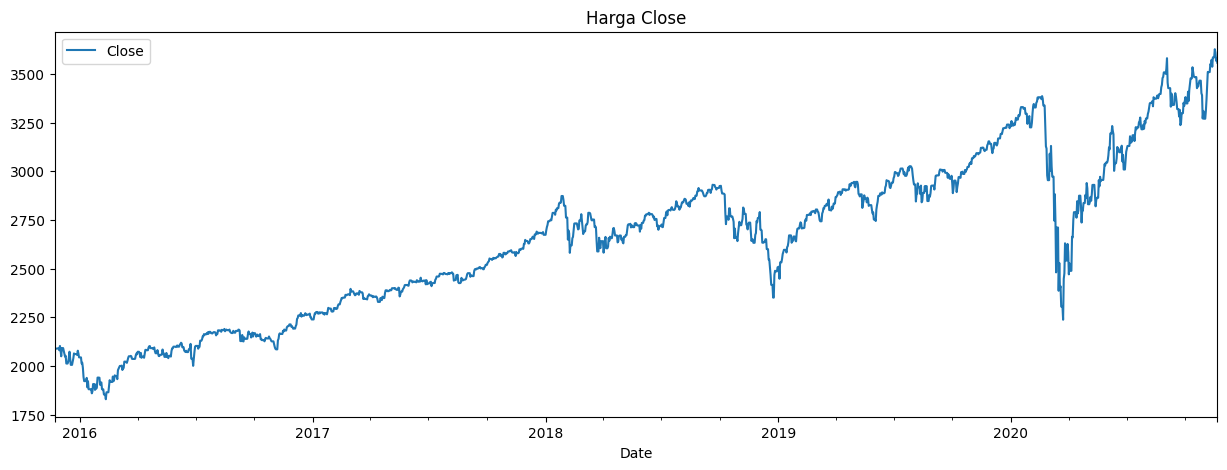

In [10]:
# Mengubah kolom 'Date' menjadi tipe datetime dan menjadikannya indeks
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ambil kolom Close, isi hari libur dengan forward fill
df_close = df[['Close']].asfreq('D').fillna(method='ffill')

# Menampilkan ukuran dataframe dan membuat plot
print("Shape:", df_close.shape)
df_close.plot(figsize=(15, 5), title="Harga Close")
plt.show()

Train test split

In [11]:
ts_train, ts_test = train_test_split(df_close, test_size=0.2, shuffle=False)
print("Train:", ts_train.shape, "| Test:", ts_test.shape)

Train: (1460, 1) | Test: (365, 1)


Normalisasi

In [12]:
scaler = MinMaxScaler()

ts_train[['Close']] = scaler.fit_transform(ts_train[['Close']])
ts_test[['Close']] = scaler.transform(ts_test[['Close']])

Dataset dan Dataloader

In [13]:
# Bagian Dataset & Dataloader
seq_len = 14  # pakai 14 hari sebagai window
bs = 32

train_set = TimeSeriesDataset(ts_train, "Close", seq_len)
trainloader = DataLoader(train_set, batch_size=bs, shuffle=False)

test_set = TimeSeriesDataset(ts_test, "Close", seq_len)
testloader = DataLoader(test_set, batch_size=bs, shuffle=False)

print("Fitur:", train_set.n_feature, "| Seq len:", train_set.n_seq)

(N, S, F): (104, 14, 1)
Note: last 3 data excluded

(N, S, F): (26, 14, 1)
Note: last 0 data excluded

Fitur: 1 | Seq len: 14


Model LSTM

In [14]:
class LSTM(nn.Module):
    def __init__(self, input_size, output_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        x, hidden = self.lstm(x, hidden)
        x = self.fc(x)
        return x, hidden

Config dan inisialisasi

In [15]:
# Membuat direktori untuk menyimpan model LSTM jika belum ada
os.makedirs("model/lstm", exist_ok=True)

# Mengatur konfigurasi hyperparameter model
config = set_config({
    "input_size": train_set.n_feature,
    "seq_len": train_set.n_seq,
    "output_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
})

# Inisialisasi model LSTM dan memindahkannya ke device (GPU/CPU)
model = LSTM(config.input_size, config.output_size,
             config.hidden_size, config.num_layers, config.dropout).to(device)

# Mendefinisikan Loss Function, Optimizer, dan Callback
criterion = nn.MSELoss(reduction="mean")
optimizer = optim.AdamW(model.parameters(), lr=0.0001)
callback = Callback(model, config, outdir="model/lstm")

Training Loop

In [16]:
def loop_fn(mode, dataset, dataloader, model, criterion, optimizer, device):
    model.train() if mode == "train" else model.eval()

    cost = 0
    for feature, target in tqdm(dataloader, desc=mode.title()):
        feature, target = feature.to(device), target.to(device)
        output, hidden = model(feature, None)
        loss = criterion(output, target)

        if mode == "train":
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        cost += loss.item() * feature.shape[0]

    return cost / len(dataset)

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch     1
Train_cost  = 0.3992 | Test_cost  = 1.1901 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    19
Train_cost  = 0.2259 | Test_cost  = 0.8135 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    20
Train_cost  = 0.2145 | Test_cost  = 0.7849 | 


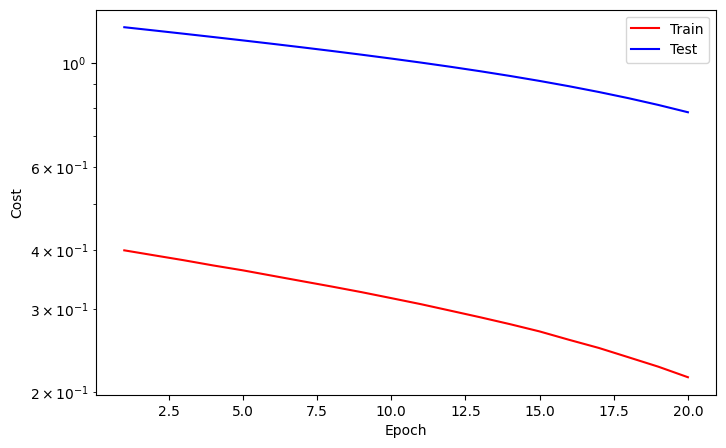

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    21
Train_cost  = 0.2030 | Test_cost  = 0.7548 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    39
Train_cost  = 0.1002 | Test_cost  = 0.3203 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    40
Train_cost  = 0.0999 | Test_cost  = 0.3207 | 


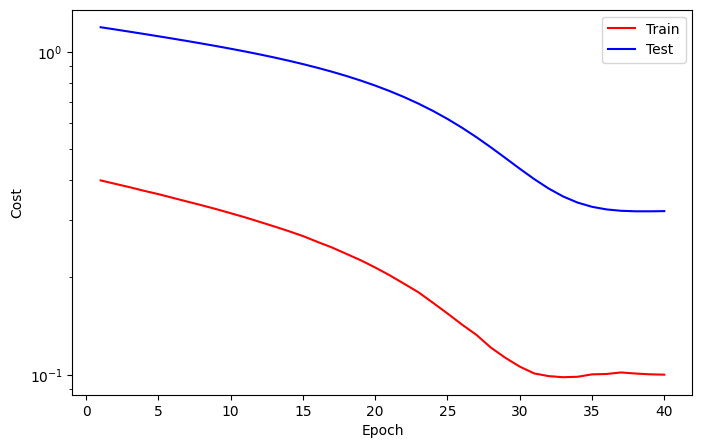

==> EarlyStop patience =  1 | Best test_cost: 0.3203


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    41
Train_cost  = 0.0986 | Test_cost  = 0.3211 | 
==> EarlyStop patience =  2 | Best test_cost: 0.3203


Train:   0%|          | 0/4 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    59
Train_cost  = 0.0878 | Test_cost  = 0.2904 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    60
Train_cost  = 0.0872 | Test_cost  = 0.2886 | 


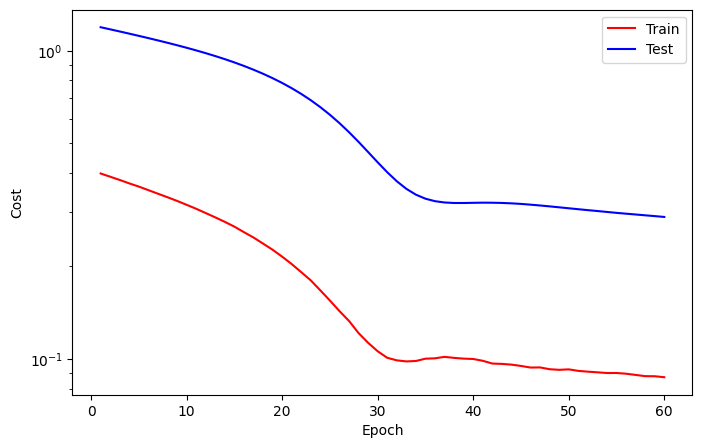

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    61
Train_cost  = 0.0872 | Test_cost  = 0.2868 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    79
Train_cost  = 0.0780 | Test_cost  = 0.2566 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    80
Train_cost  = 0.0785 | Test_cost  = 0.2549 | 


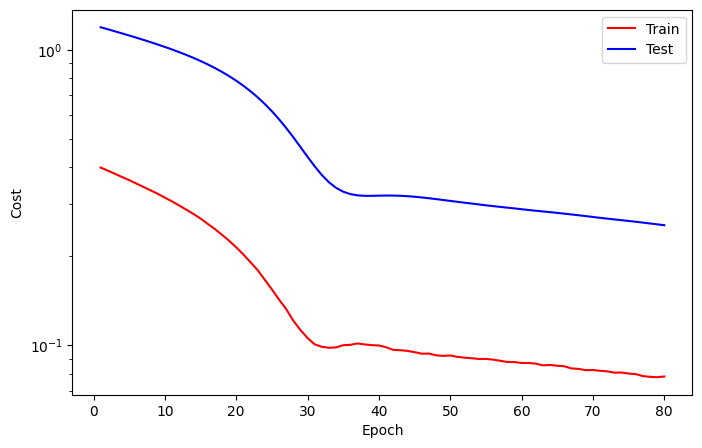

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    81
Train_cost  = 0.0778 | Test_cost  = 0.2532 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    99
Train_cost  = 0.0689 | Test_cost  = 0.2247 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   100
Train_cost  = 0.0688 | Test_cost  = 0.2229 | 


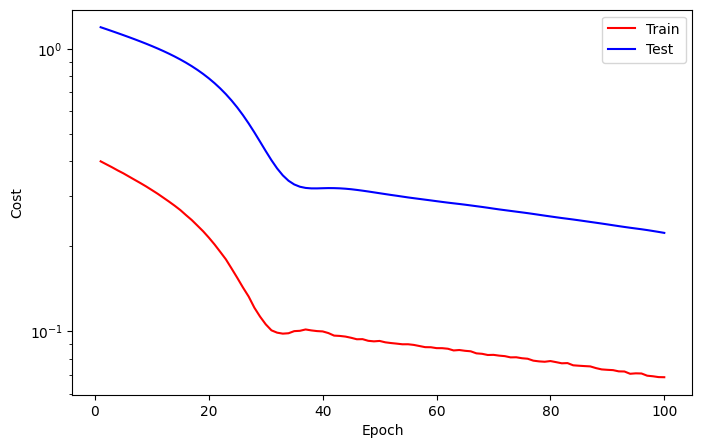

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   101
Train_cost  = 0.0679 | Test_cost  = 0.2211 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   119
Train_cost  = 0.0595 | Test_cost  = 0.1900 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   120
Train_cost  = 0.0585 | Test_cost  = 0.1881 | 


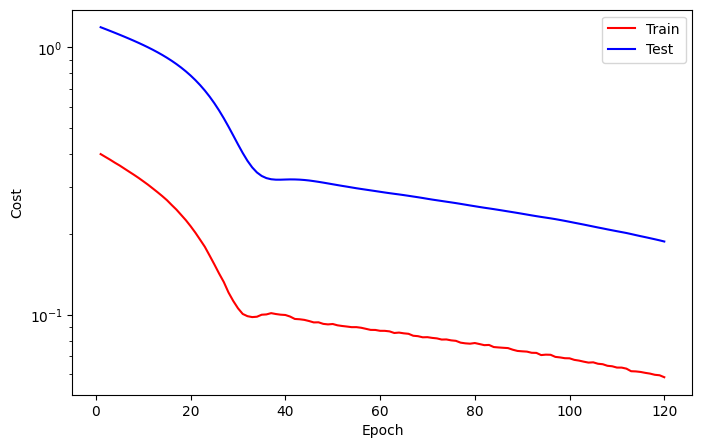

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   121
Train_cost  = 0.0581 | Test_cost  = 0.1862 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   139
Train_cost  = 0.0499 | Test_cost  = 0.1571 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   140
Train_cost  = 0.0484 | Test_cost  = 0.1557 | 


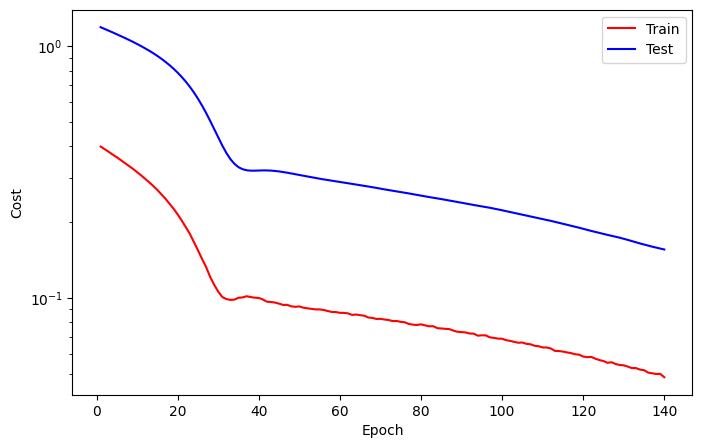

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   141
Train_cost  = 0.0486 | Test_cost  = 0.1544 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   159
Train_cost  = 0.0407 | Test_cost  = 0.1385 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   160
Train_cost  = 0.0401 | Test_cost  = 0.1383 | 


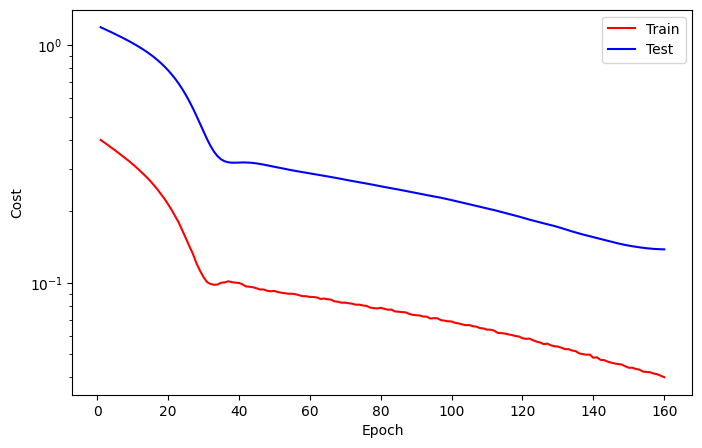

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   161
Train_cost  = 0.0398 | Test_cost  = 0.1383 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   169
Train_cost  = 0.0377 | Test_cost  = 0.1393 | 
==> EarlyStop patience =  4 | Best test_cost: 0.1377


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch   170
Train_cost  = 0.0369 | Test_cost  = 0.1396 | 
==> EarlyStop patience =  5 | Best test_cost: 0.1377
==> Execute Early Stopping at epoch: 170 | Best test_cost: 0.1377
==> Best model is saved at model/lstm


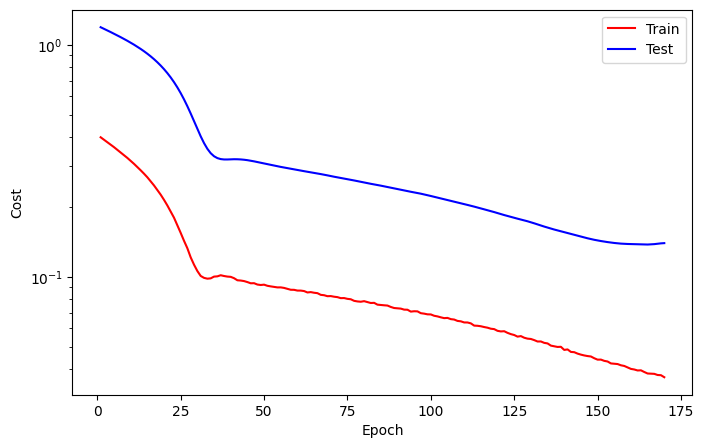

In [17]:
# Training dengan Early Stopping
while True:
    train_cost = loop_fn("train", train_set, trainloader, model, criterion, optimizer, device)
    with torch.no_grad():
        test_cost = loop_fn("test", test_set, testloader, model, criterion, optimizer, device)

    callback.log(train_cost, test_cost)
    callback.save_checkpoint()
    callback.cost_runtime_plotting()

    if callback.early_stopping(model, monitor="test_cost"):
        callback.plot_cost()
        break

Forecasting

In [18]:
import matplotlib.pyplot as plt

# Gunakan seq_len=14, sama seperti saat training
train_fc_set = TimeSeriesDataset(ts_train, "Close", seq_len)  # seq_len=14
train_fc_loader = DataLoader(train_fc_set)
test_fc_set = TimeSeriesDataset(ts_test, "Close", seq_len)
test_fc_loader = DataLoader(test_fc_set)

def data4pred(model, dataset, dataloader, device):
    model.eval()
    all_preds, all_actuals = [], []

    with torch.no_grad():
        for feature, target in dataloader:
            feature = feature.to(device)
            # Reset hidden tiap batch, ambil semua timestep
            output, _ = model(feature, None)
            # output shape: (batch, seq_len, 1)
            all_preds.extend(output[:, -1, 0].cpu().numpy())
            all_actuals.extend(target[:, -1, 0].numpy())

    plt.plot(all_actuals, label="Aktual")
    plt.plot(all_preds, label="Prediksi")
    plt.legend()

(N, S, F): (104, 14, 1)
Note: last 3 data excluded

(N, S, F): (26, 14, 1)
Note: last 0 data excluded



In [19]:
def pred4pred(model, dataset, dataloader, device, scaler, n_future=7):

    model.eval()

    all_preds = []
    all_actuals = []
    last_feature = None


    # Prediksi data test
    with torch.no_grad():
        for feature, target in dataloader:
            feature = feature.to(device)
            output, _ = model(feature, None)
            all_preds.extend(
                output[:, -1, 0].cpu().numpy()
            )
            all_actuals.extend(
                target[:, -1, 0].cpu().numpy()
            )
            last_feature = feature


    # Rolling Window Forecast

    # Ambil window terakhir
    window = last_feature[-1:, :, :].clone()
    future_preds = []

    with torch.no_grad():
        for _ in range(n_future):
            # Prediksi berdasarkan 14 hari terakhir
            output, _ = model(window, None)
            # Ambil prediksi terakhir
            next_val = output[:, -1:, :]
            future_preds.append(
                next_val.item()
            )
            # Geser window
            window = torch.cat(
                [
                    window[:, 1:, :],
                    next_val
                ],
                dim=1
            )

    # invers ke harga asli
    all_actuals_real = scaler.inverse_transform(
        np.array(all_actuals).reshape(-1, 1)
    ).flatten()

    all_preds_real = scaler.inverse_transform(
        np.array(all_preds).reshape(-1, 1)
    ).flatten()

    future_preds_real = scaler.inverse_transform(
        np.array(future_preds).reshape(-1, 1)
    ).flatten()


    # Visualisasi
    plt.figure(figsize=(15, 5))
    plt.plot(
        range(len(all_actuals_real)),
        all_actuals_real,
        label="Aktual"
    )
    plt.plot(
        range(len(all_preds_real)),
        all_preds_real,
        label="Prediksi (in-sample)"
    )
    plt.plot(
        range(
            len(all_actuals_real),
            len(all_actuals_real) + n_future
        ),
        future_preds_real,
        '--',
        label=f'Forecast {n_future} Hari'
    )
    plt.title(f'Forecast {n_future} Hari ke Depan (Harga Asli)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return future_preds_real

Visualisasi

Text(0.5, 1.0, 'Train')

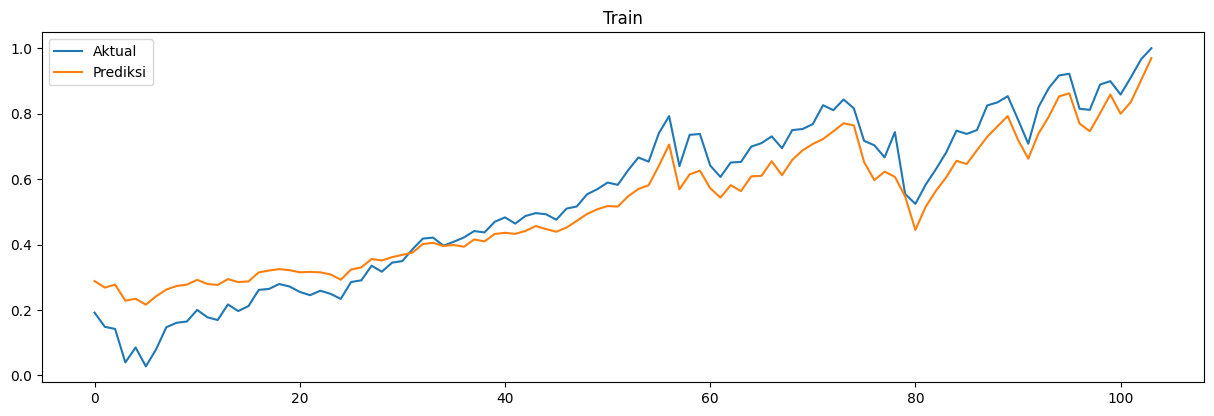

In [20]:
# Visualisasi prediksi data train
plt.figure(figsize=(15, 10))
plt.subplot(211)
data4pred(model, train_fc_set, train_fc_loader, device)
plt.title("Train")

Text(0.5, 1.0, 'Test')

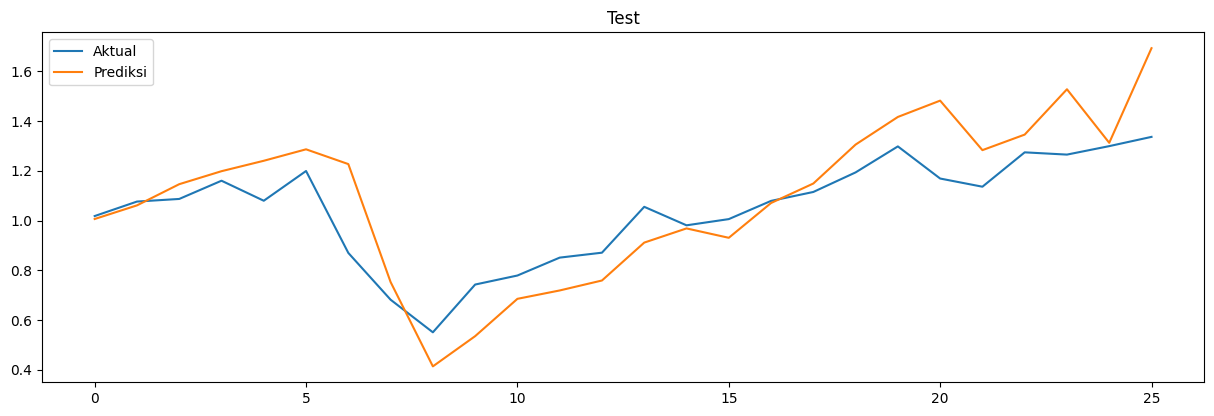

In [23]:
# Visualisasi prediksi data test
plt.figure(figsize=(15, 10))
plt.subplot(211)
data4pred(model, test_fc_set, test_fc_loader, device)
plt.title("Test")

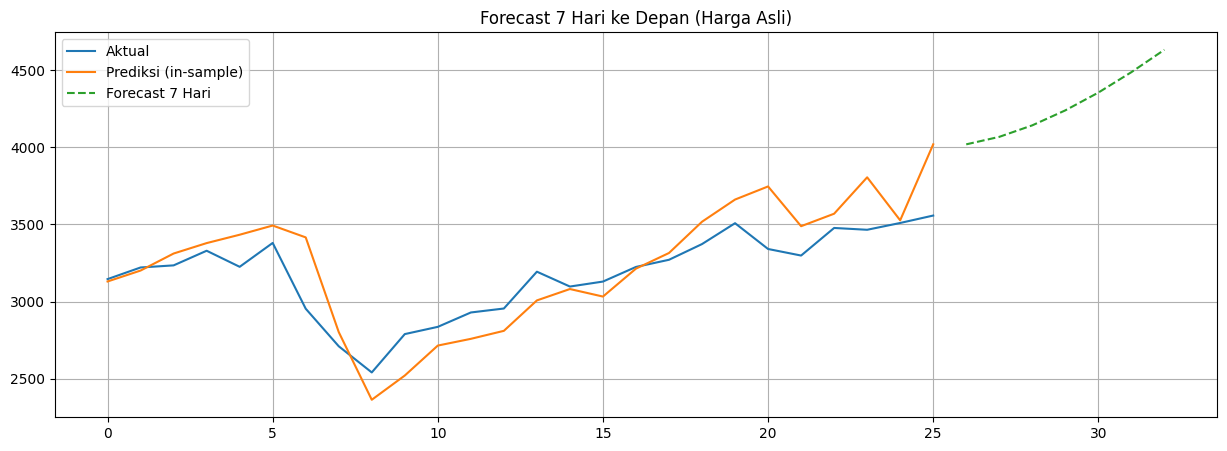

array([4018.63238931, 4067.11481112, 4141.71607571, 4238.70064818,
       4353.72463596, 4485.99040772, 4631.10413224])

In [22]:
# Visualisasi prediksi forecast
pred4pred(
    model,
    test_fc_set,
    test_fc_loader,
    device,
    scaler,
    n_future=7
)